# E20 · Learning a directed graph: Bayesian causal discovery

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | Sachs et al. (2005): single-cell flow cytometry of 11 phosphorylated proteins and lipids in human T cells, 7466 cells in 9 conditions (853 unperturbed, the rest with a known activator or inhibitor), scored against the 20-edge consensus signalling network |
| **You will learn** | Linear-Gaussian structural equation models (SEMs) as weighted DAGs · Markov equivalence: why $X \to Y$ and $Y \to X$ fit observational data identically, shown with LOO · `pm.do` - the two equivalent models disagree about interventions · NOTEARS in PyMC: a horseshoe on $W$ plus the acyclicity penalty $h(W) = \operatorname{tr} e^{W \circ W} - d$ as a `pm.Potential`, and its three problems (penalty strength, one ordering per chain, scale dependence / varsortability) · a DAG with a fixed order is just sparse regressions · exact Bayesian averaging over all orders of 11 nodes with a closed-form (BGe) score and dynamic programming · interventions as a per-cell mask that cuts incoming edges, and why the *meaning* of an intervention decides the answer · scoring directed edges against an uncertain consensus |

**E19** learned which pairs of molecules in the Sachs data are *directly* connected and ended
with the question it could not answer: which way do the arrows point? Does Raf phosphorylate
Mek, or Mek Raf? That is the question of **causal discovery**, and it is harder than it
looks. From observational data alone most directions are simply not identifiable - not
"hard to estimate" but *identical in likelihood*. This notebook shows that first, then tries
the three families of Bayesian structure learning (continuous optimisation, fixed orders,
exact averaging over orders), and finally uses what Sachs et al. actually designed their
experiment around: **interventions**, which break the symmetry - if we model them correctly.

In [1]:
import itertools
import logging
import re
import time
import warnings

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor
import pytensor.tensor as pt
import xarray as xr
from matplotlib.lines import Line2D
from pytensor.tensor.linalg import expm
from scipy.linalg import expm as scipy_expm
from scipy.special import comb, logsumexp, multigammaln

from pymc_challenges import data

RANDOM_SEED = 2005
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)  # many fits: no banner each time
BLUE, ORANGE, AQUA, GREY, RED = "#2a78d6", "#eb6834", "#1baf7a", "#8a8a86", "#c2185b"
print(f"PyMC {pm.__version__}, ArviZ {az.__version__}")


def report(idata, label, var_names):
    div = idata.sample_stats["diverging"].sum("draw").to_numpy()
    with warnings.catch_warnings():             # masked (constant) entries give 0/0 in r_hat
        warnings.simplefilter("ignore", RuntimeWarning)
        rhat = max(float(az.rhat(idata, var_names=[v])[v].max()) for v in var_names)
        ess = min(float(az.ess(idata, var_names=[v])[v].min()) for v in var_names)
    print(f"{label}: divergences per chain {div.tolist()}, max r_hat {rhat:.3f}, min bulk ESS {ess:.0f}")

PyMC 6.3.2, ArviZ 1.3.0


## 1 · The data: one observational and eight interventional conditions

The same registry files as E19: log(intensity + 10) of the 11 molecules, the 0/1 condition
indicators, and the 20-edge consensus network from the literature.

In [2]:
data.describe("sachs")
sachs = data.load("sachs")
V = list(sachs.columns[:11])
P = len(V)
conditions = list(sachs.columns[11:])
label = sachs[conditions].apply(lambda r: "+".join(c for c in conditions if r[c] == 1), axis=1).to_numpy()
consensus_edges = re.findall(r"\d+\. (\w+) --> (\w+)", data.path("sachs_consensus").read_text())
TRUE = np.zeros((P, P), bool)                   # TRUE[k, j]: consensus edge k -> j
for a, b in consensus_edges:
    TRUE[V.index(a), V.index(b)] = True
SKEL = TRUE | TRUE.T
IU = np.triu_indices(P, 1)
print(f"{TRUE.sum()} consensus edges:", ", ".join(f"{a}->{b}" for a, b in consensus_edges))

sachs: 7466 cells from 9 conditions, ALL conditions pooled. Columns 1-11 are log(x + 10) of the raw intensities (raf mek plc pip2 pip3 erk akt pka pkc p38 jnk); columns 12-20 are 0/1 condition indicators (cd3_cd28 stimulation, icam2, and the reagents aktinhib g0076 psitect u0126 ly pma b2camp). The 853 cells with cd3_cd28 = 1 and all reagents 0 are the purely observational set.
  source: Sachs et al. (2005, Science 308:523), single-cell flow cytometry of 11 phosphoproteins/lipids in human T cells, via the CMU example-causal-datasets repository.
  url:    https://raw.githubusercontent.com/cmu-phil/example-causal-datasets/main/real/sachs/data/sachs.2005.continuous.discrete.experimental.mixed.maximum.2.txt
20 consensus edges: erk->akt, mek->erk, pip2->pkc, pip3->akt, pip3->pip2, pip3->plc, pka->akt, pka->erk, pka->jnk, pka->mek, pka->p38, pka->raf, pkc->jnk, pkc->mek, pkc->p38, pkc->pka, pkc->raf, plc->pip2, plc->pkc, raf->mek


Every condition adds one reagent to a stimulus. Sachs et al. chose the reagents because each
acts on **one known molecule**: two activators and five inhibitors.

In [3]:
TARGETS = {  # condition -> (targeted molecule, kind)
    "cd3_cd28+aktinhib": ("akt", "inhibitor"), "cd3_cd28+g0076": ("pkc", "inhibitor"),
    "cd3_cd28+psitect": ("pip2", "inhibitor"), "cd3_cd28+u0126": ("mek", "inhibitor"),
    "cd3_cd28+ly": ("pip3", "inhibitor"), "pma": ("pkc", "activator"), "b2camp": ("pka", "activator"),
}
X_all = sachs[V].to_numpy()
obs = label == "cd3_cd28"
mu_obs, sd_obs = X_all[obs].mean(0), X_all[obs].std(0)
Z_all = (X_all - mu_obs) / sd_obs               # every cell on the scale of the unperturbed cells
Z = Z_all[obs]
N = len(Z)
table = pd.DataFrame({"cells": pd.Series(label).value_counts()})
table["target"] = [TARGETS.get(c, ("-", ""))[0] for c in table.index]
table["kind"] = [TARGETS.get(c, ("", "none (baseline)" if c == "cd3_cd28" else "extra stimulus"))[1] for c in table.index]
means = pd.DataFrame(Z_all, columns=V).groupby(label).mean()
table["mean shift of target (obs sd)"] = [means.loc[c, t] if t != "-" else np.nan for c, t in zip(table.index, table.target)]
table.round(2)

,cells,target,kind,mean shift of target (obs sd)
pma,913,pkc,activator,0.21
cd3_cd28+aktinhib,911,akt,inhibitor,0.30
cd3_cd28+icam2,902,-,extra stimulus,NaN
cd3_cd28,853,-,none (baseline),NaN
cd3_cd28+ly,848,pip3,inhibitor,-0.22
cd3_cd28+psitect,810,pip2,inhibitor,-1.88
cd3_cd28+u0126,799,mek,inhibitor,5.52
cd3_cd28+g0076,723,pkc,inhibitor,3.86
b2camp,707,pka,activator,-0.04


Look at the last column before trusting the word "target". The two *activators* barely move
their targets' measured level (PMA +0.21 sd on PKC, b2cAMP -0.04 sd on PKA; both conditions
also lack the CD3/CD28 stimulus, so their baseline differs too). Of the inhibitors, only
psitectorigenin pushes its target down (-1.9 sd on PIP2). U0126, a Mek inhibitor, *raises*
phospho-Mek by 5.5 sd, and G06976, a PKC inhibitor, raises PKC by 3.9 sd. The reagents block
the **activity** of a kinase, and what the cytometer measures is its **phosphorylation**; the
two need not move together. Hold on to this - section 6 turns on it.

## 2 · Linear-Gaussian SEMs and Markov equivalence

A linear-Gaussian structural equation model writes every variable as a linear function of
its **parents** plus independent noise:

$$
X_j = \sum_{k} W_{kj} X_k + \varepsilon_j, \qquad \varepsilon_j \sim \text{Normal}(0, \sigma_j^2),
\qquad \text{i.e.}\quad X = W^\top X + \varepsilon ,
$$

with $W_{kj} \ne 0$ exactly when there is an arrow $k \to j$, and the arrows forming a
directed acyclic graph (DAG). The joint distribution is Gaussian with covariance
$\Sigma = (I - W)^{-\top} D (I - W)^{-1}$, $D = \operatorname{diag}(\sigma_j^2)$.

Here is the catch. A bivariate Gaussian has 5 parameters (2 means, 2 variances, 1
covariance). The model PKA $\to$ Erk has 5 (two intercepts, one slope, two noise sds) and so
has Erk $\to$ PKA, and each can reproduce *any* bivariate Gaussian. On observational data
they are the same model in two parametrisations. Let us fit both in PyMC on the 853
unperturbed cells and compare them by LOO.

In [4]:
def pair_model(cause, effect, conds, target=None):
    """Two-node SEM cause -> effect with one intercept per condition. In cells where `target`
    is intervened it gets its own noise sd and, if it is the effect, loses its parent."""
    rows = np.isin(label, conds)
    ci = pd.Index(conds).get_indexer(label[rows])
    xc, xe = Z_all[rows, V.index(cause)], Z_all[rows, V.index(effect)]
    hit = np.zeros(rows.sum(), int)
    if target is not None:
        hit = np.isin(label[rows], [c for c, (t, _) in TARGETS.items() if t == target]).astype(int)
    int_c = hit if target == cause else np.zeros_like(hit)
    int_e = hit if target == effect else np.zeros_like(hit)
    with pm.Model(coords={"cond": conds, "cell": np.arange(rows.sum())}) as model:
        a_c = pm.Normal("a_cause", 0.0, 2.0, dims="cond")
        a_e = pm.Normal("a_effect", 0.0, 2.0, dims="cond")
        s_c = pm.HalfNormal("s_cause", 1.0, shape=2)          # [natural, intervened]
        s_e = pm.HalfNormal("s_effect", 1.0, shape=2)
        b = pm.Normal("b", 0.0, 1.0)
        x_c = pm.Normal(cause, a_c[ci], s_c[int_c], observed=xc, dims="cell")
        # the do-operator as a mask: an intervened effect does not listen to its parent
        pm.Normal(effect, a_e[ci] + b * x_c * (1 - int_e), s_e[int_e], observed=xe, dims="cell")
    return model


def fit_pair(cause, effect, conds, target=None):
    model = pair_model(cause, effect, conds, target)
    with model:
        idata = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
        pm.compute_log_likelihood(idata, progressbar=False)
    ll = idata.log_likelihood
    idata.log_likelihood["joint"] = ll[cause] + ll[effect]   # a cell's density = product over nodes
    loo = az.loo(idata, var_name="joint")
    return model, idata, loo


pair_obs = {}
for c, e in [("pka", "erk"), ("erk", "pka")]:
    model, idata, loo = fit_pair(c, e, ["cd3_cd28"])
    report(idata, f"{c} -> {e}", ["b", "s_cause", "s_effect"])
    pair_obs[f"{c} -> {e}"] = (model, idata, loo)
az.compare({k: v[2] for k, v in pair_obs.items()}, round_to=1)[["elpd", "elpd_diff", "dse", "p"]]

/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


pka -> erk: divergences per chain [0, 0, 0, 0], max r_hat 1.004, min bulk ESS 2278


erk -> pka: divergences per chain [0, 0, 1, 0], max r_hat 1.001, min bulk ESS 2681


/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,elpd,elpd_diff,dse,p
pka -> erk,-2371.4,0.0,0.0,11.7
erk -> pka,-2371.5,-0.1,0.1,11.9


Both fits are clean (one divergence in 8000 draws, r_hat at most 1.004), and the two models
are indistinguishable: 0.1 elpd apart with a
standard error of 0.1, out of 2371. The slope is not the point - any linear-Gaussian
pair can be written in either direction with the same fit - and no amount of data changes
this. (The residual 0.1 is the priors: Normal(0, 1) on a slope means something slightly
different in each direction.)

**Why direction matters anyway: `pm.do`.** The two fits make the same predictions for
*observed* cells, but they are different causal claims, and they disagree about what happens
when we *set* PKA ourselves. `pm.do(model, {"pka": value})` replaces the PKA node by a
constant, cutting whatever arrows pointed into it, and the posterior predictive of Erk in the
modified model answers "what would Erk be if we forced PKA up by 2 standard deviations?"

In [5]:
for name, (model, idata, _) in pair_obs.items():
    forced = pm.do(model, {"pka": np.full(N, 2.0)})           # same shape as the observed node
    pp = pm.sample_posterior_predictive(idata.isel(draw=slice(None, None, 4)), model=forced, var_names=["erk"],
                                        random_seed=RANDOM_SEED, progressbar=False)
    shift = pp.posterior_predictive["erk"].mean("cell")
    print(f"{name}: E[erk | do(pka = +2 sd)] = {float(shift.mean()):+.2f} sd "
          f"(94% interval {np.quantile(shift, 0.03):+.2f} to {np.quantile(shift, 0.97):+.2f})")
    del pp
del pair_obs

pka -> erk: E[erk | do(pka = +2 sd)] = +0.71 sd (94% interval +0.57 to +0.85)
erk -> pka: E[erk | do(pka = +2 sd)] = -0.00 sd (94% interval -0.08 to +0.09)


Same data, same fit, opposite answers. If PKA drives Erk, forcing PKA up by 2 sd moves Erk
by +0.71 sd (94% interval 0.57 to 0.85). If Erk drives PKA, forcing PKA does nothing to Erk
(-0.00, interval -0.08 to +0.09). Observational data cannot tell us which prediction to
believe; the rest of the notebook is about what can.

### Three nodes: equivalence classes, and the one pattern that *is* visible

With more nodes, the rule (Verma & Pearl 1990) is: two DAGs are **Markov equivalent** -
indistinguishable from observational data - if and only if they have the same skeleton and
the same **v-structures** (colliders $A \to B \leftarrow C$ with $A$, $C$ not adjacent).
Chains $A \to B \to C$, $A \leftarrow B \leftarrow C$ and forks $A \leftarrow B \to C$ all say
"$A \perp C \mid B$"; the collider says "$A \perp C$, but not given $B$" and stands alone.

To score whole DAGs quickly and exactly we switch from sampling to a **closed-form marginal
likelihood**. With a conjugate Normal-Wishart prior on the joint Gaussian, the marginal
likelihood of a DAG factorises over families (a node and its parents) and every family term is
a ratio of determinants and multivariate gamma functions: the **BGe score** (Geiger &
Heckerman 1994; the corrected formula of Kuipers, Moffa & Heckerman 2014). Its key property is
**score equivalence**: Markov-equivalent DAGs get *exactly* the same marginal likelihood, so
any preference between them can only come from the prior.

In [6]:
AM = 1.0                                         # prior pseudo-count for the mean (BGe alpha_mu)
T0 = AM**2 / (AM + 1)                            # prior scale matrix T0 = T0 * I (Kuipers et al. 2014)


def bge_stats(Zd):
    n = len(Zd)
    xbar = Zd.mean(0)
    R = T0 * np.eye(Zd.shape[1]) + (Zd - xbar).T @ (Zd - xbar) + n * AM / (n + AM) * np.outer(xbar, xbar)
    return n, R


def bge_logml(stats, Y):
    """log marginal likelihood of the columns Y under the BGe prior (alpha_w - p = alpha_mu + 1)."""
    n, R = stats
    l = len(Y)
    if l == 0:
        return 0.0
    a = AM + 1 + l
    return (-l * n / 2 * np.log(np.pi) + l / 2 * np.log(AM / (n + AM))
            + multigammaln((n + a) / 2, l) - multigammaln(a / 2, l)
            + a / 2 * l * np.log(T0) - (n + a) / 2 * np.linalg.slogdet(R[np.ix_(Y, Y)])[1])


def family_score(stats, j, parents):
    return bge_logml(stats, [j, *parents]) - bge_logml(stats, list(parents))


st = bge_stats(Z)
r, m = V.index("raf"), V.index("mek")
print("raf -> mek:", family_score(st, r, []) + family_score(st, m, [r]))
print("mek -> raf:", family_score(st, m, []) + family_score(st, r, [m]))

raf -> mek: -2147.1238314917787
mek -> raf: -2147.1238314917787


Identical to every printed digit. Now all 25 DAGs on three nodes. We take PKC, p38 and Jnk:
the consensus says PKC $\to$ p38 and PKC $\to$ Jnk (a fork), and E19 found p38 and Jnk slightly
*negatively* correlated (-0.08) but *positively* related (partial correlation +0.14) once PKC
and the others are held fixed.

In [7]:
def all_dags(k):
    """All DAGs on k nodes as tuples of parent sets."""
    subsets = [[s for r_ in range(k) for s in itertools.combinations([i for i in range(k) if i != j], r_)]
               for j in range(k)]
    out = []
    for pas in itertools.product(*subsets):
        adj = np.zeros((k, k), bool)
        for j, pa in enumerate(pas):
            adj[list(pa), j] = True
        A = adj.astype(int)
        if all(np.trace(np.linalg.matrix_power(A, q)) == 0 for q in range(2, k + 1)):   # no directed cycle
            out.append(pas)
    return out


def eq_class(pas):
    """(skeleton, v-structures): the signature of a Markov equivalence class."""
    skel = frozenset(frozenset((k, j)) for j, pa in enumerate(pas) for k in pa)
    vs = frozenset((min(a, c), j, max(a, c)) for j, pa in enumerate(pas) for a, c in itertools.combinations(pa, 2)
                   if frozenset((a, c)) not in skel)
    return skel, vs


def dag_text(pas, names):
    arrows = [f"{names[k]}→{names[j]}" for j, pa in enumerate(pas) for k in pa]
    return ", ".join(arrows) if arrows else "(empty)"


def triple_posterior(Zd, INTd, nodes):
    """Exact posterior over all 25 DAGs on `nodes` (uniform prior), family by family."""
    stats = [bge_stats(Zd[~INTd[:, j]][:, nodes]) for j in nodes]
    dags = all_dags(len(nodes))
    logml = np.array([sum(family_score(stats[j], j, pa) for j, pa in enumerate(pas)) for pas in dags])
    post = np.exp(logml - logsumexp(logml))
    return dags, logml, post


TRIPLE = [V.index(v) for v in ["pkc", "p38", "jnk"]]
dags3, logml3, post3 = triple_posterior(Z, np.zeros_like(Z, bool), TRIPLE)
print(f"{len(dags3)} DAGs, {len({eq_class(d) for d in dags3})} equivalence classes")
tri = pd.DataFrame({"DAG": [dag_text(d, ["pkc", "p38", "jnk"]) for d in dags3],
                    "class": pd.factorize(pd.Series([eq_class(d) for d in dags3]))[0],
                    "log ML - max": logml3 - logml3.max(), "posterior, 853 unperturbed": post3})
tri.sort_values("log ML - max", ascending=False).head(9).round(3)

25 DAGs, 11 equivalence classes


,DAG,class,log ML - max,"posterior, 853 unperturbed"
22,"p38→pkc, jnk→pkc",10,0.000,0.428
24,"p38→pkc, jnk→pkc, jnk→p38",7,-1.513,0.094
11,"pkc→p38, jnk→p38, pkc→jnk",7,-1.513,0.094
23,"p38→pkc, jnk→pkc, p38→jnk",7,-1.513,0.094
21,"jnk→pkc, pkc→p38, jnk→p38",7,-1.513,0.094
7,"pkc→p38, pkc→jnk, p38→jnk",7,-1.513,0.094
15,"p38→pkc, pkc→jnk, p38→jnk",7,-1.513,0.094
5,"pkc→p38, pkc→jnk",5,-5.259,0.002
19,"jnk→pkc, pkc→p38",5,-5.259,0.002


The 25 DAGs fall into 11 equivalence classes, and within a class the log marginal likelihood
is identical to the last digit: the six complete DAGs (class 7) all sit 1.5 below the best,
for example. The winner is a class of *one*: the collider p38 $\to$ PKC $\leftarrow$ Jnk,
with posterior probability 0.43 - the one direction observational data can pin down,
because p38 and Jnk are nearly independent until PKC is conditioned on. The consensus fork
PKC $\to$ p38, PKC $\to$ Jnk belongs to a class of three (with the two chains) at 5.3 log units
below: posterior 0.002 each. So the only arrows the unperturbed cells *can* orient point
**into** PKC, against the literature. Keep it in mind for section 6.

## 3 · NOTEARS in PyMC: learning the DAG by continuous optimisation

Searching over DAGs is combinatorial: 29,281 DAGs on 5 nodes, about $3 \times 10^{22}$ on 11.
Zheng et al. (2018, *DAGs with NO TEARS*) turned the search into a smooth problem. For a
weighted adjacency matrix $W$,

$$
h(W) = \operatorname{tr}\big(e^{W \circ W}\big) - d \ \ge 0, \qquad h(W) = 0 \iff W \text{ is a DAG},
$$

because $\operatorname{tr}(A^k)$ sums the weights of closed walks of length $k$, and the
matrix exponential adds them all up with positive weights. $h$ is differentiable, so it can go
into a PyMC model as a **soft constraint**: `pm.Potential("acyclic", -lam * h(W))`, with
`expm` from `pytensor.tensor.linalg`. NUTS needs its gradient; the analytic one is
$\nabla h = 2\,W \circ (e^{W \circ W})^\top$, so we check PyTensor against it first.

In [8]:
A = pt.matrix("A")
h_A = pt.trace(expm(A * A)) - A.shape[0]
h_and_grad = pytensor.function([A], [h_A, pytensor.grad(h_A, A)])
W_test = rng.normal(0.0, 0.5, (5, 5))
np.fill_diagonal(W_test, 0.0)
h_val, g_val = h_and_grad(W_test)
print(f"h = {h_val:.4f}; max |autodiff - analytic gradient| = "
      f"{np.abs(g_val - 2 * W_test * scipy_expm(W_test * W_test).T).max():.1e}")

h = 0.5077; max |autodiff - analytic gradient| = 4.4e-16


The gradient is right to machine precision. On top of $h$ we put the same regularised
horseshoe as in E19 on every $W_{kj}$, and the SEM likelihood
$X_{ij} \sim \text{Normal}\big((XW)_{ij}, \sigma_j\big)$: a Bayesian NOTEARS. How strong should
the penalty be? $h$ is small for weak cycles (a two-cycle with weights $a$ and $b$ costs about
$(ab)^2$), while the log-likelihood of 853 cells rewards a two-cycle by hundreds of units, so
$\lambda$ has to be large. We try a modest $\lambda = 100$ and a severe $\lambda = 10^5$.

In [9]:
def notears_model(D, lam, shared_sigma=False, p0=2.0):
    n = len(D)
    mask = 1.0 - np.eye(P)
    tau0 = p0 / (P - 1 - p0) / np.sqrt(n)
    with pm.Model(coords={"from": V, "to": V}) as model:
        sigma = pm.HalfNormal("sigma", 1.0) if shared_sigma else pm.HalfNormal("sigma", 1.0, dims="to")
        tau = pm.HalfCauchy("tau", 1.0)
        lam_ = pm.HalfCauchy("lam", 1.0, dims=("from", "to"))
        c2 = pm.InverseGamma("c2", 2.0, 2.0)
        t = tau0 * tau
        lam_tilde = pt.sqrt(c2 * lam_**2 / (c2 + t**2 * lam_**2))
        z = pm.Normal("z_raw", 0.0, 1.0, dims=("from", "to"))
        W = pm.Deterministic("W", z * lam_tilde * t * mask, dims=("from", "to"))
        h = pm.Deterministic("h", pt.trace(expm(W * W)) - P)
        pm.Potential("acyclic", -lam * h)
        pm.Normal("x", pt.as_tensor(D) @ W, sigma, observed=D)
    return model


def fit_notears(D, lam, shared_sigma=False, label_=""):
    t0 = time.time()
    with notears_model(D, lam, shared_sigma):
        idata = pm.sample(target_accept=0.95, random_seed=RANDOM_SEED, progressbar=False, var_names=["W", "h", "tau"])
    print(f"{label_}: {time.time() - t0:.0f} s")
    report(idata, "  ", ["W", "tau"])
    Wd = idata.posterior["W"].to_numpy()                          # chain, draw, from, to
    per_chain = (np.abs(Wd) > 0.1).mean(1)                        # P(|W_kj| > 0.1) in each chain
    print("  mean h(W) per chain:", idata.posterior["h"].mean("draw").to_numpy().round(3))
    return per_chain


def edge_list(Pm, thresh=0.5):
    return ", ".join(f"{V[k]}→{V[j]}" for k, j in zip(*np.nonzero(Pm > thresh)))


nt = {}
nt["lam 100"] = fit_notears(Z, 100.0, label_="NOTEARS, standardised, lambda = 100")
nt["lam 1e5"] = fit_notears(Z, 1e5, label_="NOTEARS, standardised, lambda = 100000")
for key in nt:
    for c in range(4):
        print(f"{key}, chain {c}: {edge_list(nt[key][c])}")

NOTEARS, standardised, lambda = 100: 14 s
  : divergences per chain [8, 6, 14, 4], max r_hat 1.013, min bulk ESS 203
  mean h(W) per chain: [0.856 0.855 0.858 0.857]


NOTEARS, standardised, lambda = 100000: 9 s
  : divergences per chain [1, 4, 2, 4], max r_hat 1.737, min bulk ESS 6
  mean h(W) per chain: [0. 0. 0. 0.]
lam 100, chain 0: raf→mek, mek→raf, pip2→pip3, pip3→plc, pip3→pip2, erk→akt, akt→erk, akt→pka, pka→akt, pkc→p38, pkc→jnk, p38→pkc, p38→jnk, jnk→pkc
lam 100, chain 1: raf→mek, mek→raf, pip2→pip3, pip3→plc, pip3→pip2, erk→akt, akt→erk, akt→pka, pka→akt, pkc→p38, pkc→jnk, p38→pkc, p38→jnk, jnk→pkc
lam 100, chain 2: raf→mek, mek→raf, pip2→pip3, pip3→plc, pip3→pip2, erk→akt, akt→erk, akt→pka, pka→akt, pkc→p38, pkc→jnk, p38→pkc, p38→jnk, jnk→pkc
lam 100, chain 3: raf→mek, mek→raf, pip2→pip3, pip3→plc, pip3→pip2, erk→akt, akt→erk, akt→pka, pka→akt, pkc→p38, pkc→jnk, p38→pkc, p38→jnk, jnk→pkc
lam 1e5, chain 0: raf→mek, pip3→pip2, akt→erk, akt→pka, pkc→p38, jnk→pkc
lam 1e5, chain 1: raf→mek, pip2→pip3, akt→erk, akt→pka, pkc→p38, pkc→jnk
lam 1e5, chain 2: mek→raf, pip3→pip2, erk→akt, akt→pka, p38→pkc, jnk→pkc
lam 1e5, chain 3: raf→mek, pip2→pip3

**$\lambda = 100$: not a DAG.** The chains agree with each other (r_hat 1.01) - on a graph
with six two-cycles: Raf $\rightleftarrows$ Mek, PIP2 $\rightleftarrows$ PIP3, Erk
$\rightleftarrows$ Akt, Akt $\rightleftarrows$ PKA, PKC $\rightleftarrows$ p38 and PKC
$\rightleftarrows$ Jnk, and $h(W) \approx 0.86$ in every chain. With 853 cells, splitting each
association over both directions is worth more likelihood than the penalty costs. This is
the undirected graph of E19 written twice, not a causal model.

**$\lambda = 10^5$: a DAG in every chain, a different DAG in each.** Now $h(W) = 0.000$, and all
four chains find the same six-edge skeleton - but r_hat is 1.74 and the minimum ESS is 6.
The per-chain edge lists above show why: chain 2 says Mek $\to$ Raf, the others Raf $\to$ Mek;
chains 0 and 2 say PIP3 $\to$ PIP2, chains 1 and 3 the reverse; the PKC-p38-Jnk triangle is
oriented three different ways. Only Akt $\to$ PKA is shared by all four chains (and it is the
reverse of the consensus). The picture makes it concrete.

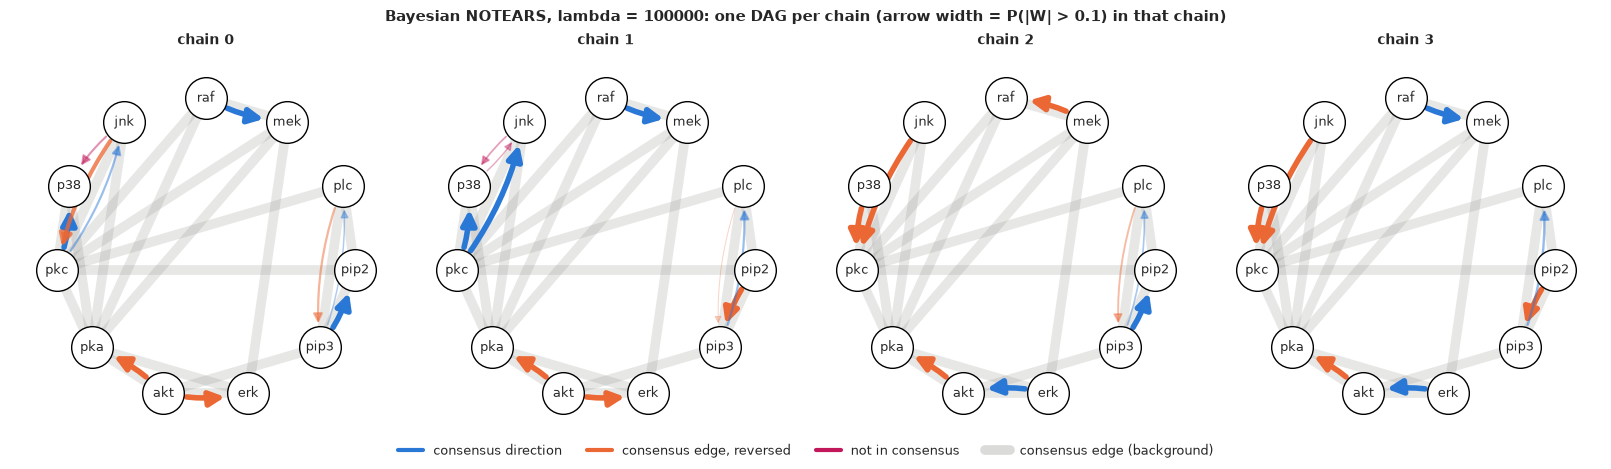

In [10]:
def draw_dag(ax, E, title, thresh=0.05, show_truth=True):
    """Arrow k -> j with width and opacity = E[k, j]; blue = consensus direction,
    orange = reversed consensus edge, red = not in the consensus."""
    angle = np.pi / 2 - 2 * np.pi * np.arange(P) / P
    xy = np.c_[np.cos(angle), np.sin(angle)]
    if show_truth:
        for k, j in zip(*np.nonzero(TRUE)):
            ax.plot(*xy[[k, j]].T, color=GREY, lw=7, alpha=0.2, solid_capstyle="round", zorder=1)
    for k, j in zip(*np.nonzero(E > thresh)):
        w = float(E[k, j])
        color = BLUE if TRUE[k, j] else ORANGE if TRUE[j, k] else RED
        ax.annotate("", xy=xy[j], xytext=xy[k], zorder=2,
                    arrowprops=dict(arrowstyle="-|>", color=color, lw=0.5 + 3.5 * w, alpha=0.25 + 0.75 * w,
                                    shrinkA=17, shrinkB=17, mutation_scale=10 + 12 * w,
                                    connectionstyle="arc3,rad=0.12"))
    ax.scatter(*xy.T, s=900, color="white", edgecolor="k", zorder=3)
    for j in range(P):
        ax.text(*xy[j], V[j], ha="center", va="center", fontsize=9, zorder=4)
    ax.set(xlim=(-1.3, 1.3), ylim=(-1.3, 1.3), aspect="equal")
    ax.set_title(title, fontsize=10)
    ax.axis("off")


DAG_LEGEND = [Line2D([], [], color=BLUE, lw=3), Line2D([], [], color=ORANGE, lw=3), Line2D([], [], color=RED, lw=3),
              Line2D([], [], color=GREY, lw=7, alpha=0.3)]
DAG_LABELS = ["consensus direction", "consensus edge, reversed", "not in consensus", "consensus edge (background)"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4.6))
for c, ax in enumerate(axes):
    draw_dag(ax, nt["lam 1e5"][c], f"chain {c}")
fig.legend(DAG_LEGEND, DAG_LABELS, loc="lower center", ncol=4, fontsize=9)
fig.suptitle("Bayesian NOTEARS, lambda = 100000: one DAG per chain (arrow width = P(|W| > 0.1) in that chain)",
             fontsize=11);

Each chain is a single DAG with near-certain edges (thick arrows), and each chain is sure of
something the others deny. This is not a sampler bug that more tuning would fix. To turn
Raf $\to$ Mek into Mek $\to$ Raf, a chain must pass either through "no edge" (losing hundreds
of log-likelihood units) or through "both edges" (a cycle, charged $\lambda h$ with
$\lambda = 10^5$). The penalty that makes the answer acyclic also walls the orderings off from
each other. The posterior is **multimodal over orderings**, a chain explores the mode it was
initialised in, and "the" answer depends on the random start. Pooling the four chains is not
a posterior either: there is no reason the modes were visited in proportion to their mass.

### Scale: the direction NOTEARS finds depends on the units

The original NOTEARS uses a least-squares loss, which is a Gaussian likelihood with **one
noise variance shared by all nodes**. Under that assumption direction *is* identifiable
(Peters & Bühlmann 2014), and the signal it exploits is that variance tends to grow along the
causal order, because each node adds its own noise to what it inherits. That is exactly why
it is fragile. Reisach, Seiler
& Weichwald (2021, *Beware of the simulated DAG!*) showed that the benchmarks on which
continuous methods shine are **varsortable**: sort the variables by variance and you have the
causal order. On real data the variances are set by antibody brightness and the $\log(x + 10)$
transform as much as by biology, and rescaling a variable changes the "causal" order.

We fit the shared-$\sigma$ version twice: on the log-intensities as they are, and standardised.

In [11]:
Xc = X_all[obs] - mu_obs                         # raw log-intensities, centred but NOT rescaled
var_raw = Xc.var(0)
print("variance of each molecule (log scale):", dict(zip(V, var_raw.round(2))))
k_, j_ = np.nonzero(TRUE)
print(f"varsortability of the consensus: {np.mean(var_raw[k_] < var_raw[j_]):.2f} of its 20 edges point "
      "from lower to higher variance")
nt["raw, shared sigma"] = fit_notears(Xc, 1e5, shared_sigma=True, label_="NOTEARS, raw scale, one shared sigma")
nt["std, shared sigma"] = fit_notears(Z, 1e5, shared_sigma=True, label_="NOTEARS, standardised, one shared sigma")
for key in ["raw, shared sigma", "std, shared sigma"]:
    for c in range(4):
        Pm = nt[key][c]
        kk, jj = np.nonzero(Pm > 0.5)
        print(f"{key}, chain {c}: {np.mean(var_raw[kk] < var_raw[jj]):.2f} of {len(kk)} edges low -> high variance; "
              f"{edge_list(Pm)}")

variance of each molecule (log scale): {'raf': np.float64(0.26), 'mek': np.float64(0.17), 'plc': np.float64(0.16), 'pip2': np.float64(0.67), 'pip3': np.float64(0.28), 'erk': np.float64(0.24), 'akt': np.float64(0.26), 'pka': np.float64(0.47), 'pkc': np.float64(0.18), 'p38': np.float64(0.15), 'jnk': np.float64(0.48)}
varsortability of the consensus: 0.45 of its 20 edges point from lower to higher variance


NOTEARS, raw scale, one shared sigma: 7 s
  : divergences per chain [15, 31, 5, 11], max r_hat 1.734, min bulk ESS 6
  mean h(W) per chain: [0. 0. 0. 0.]


NOTEARS, standardised, one shared sigma: 7 s
  : divergences per chain [11, 4, 7, 4], max r_hat 1.734, min bulk ESS 6
  mean h(W) per chain: [0. 0. 0. 0.]
raw, shared sigma, chain 0: 1.00 of 8 edges low -> high variance; mek→raf, plc→pip3, pip3→pip2, erk→akt, akt→pka, pkc→jnk, p38→pkc, p38→jnk
raw, shared sigma, chain 1: 0.88 of 8 edges low -> high variance; mek→raf, plc→pip3, pip3→pip2, erk→akt, akt→pka, pkc→p38, pkc→jnk, p38→jnk
raw, shared sigma, chain 2: 0.88 of 8 edges low -> high variance; mek→raf, plc→pip3, pip3→pip2, akt→erk, akt→pka, pkc→jnk, p38→pkc, p38→jnk
raw, shared sigma, chain 3: 0.75 of 8 edges low -> high variance; raf→mek, plc→pip3, pip3→pip2, erk→akt, akt→pka, pkc→p38, pkc→jnk, p38→jnk
std, shared sigma, chain 0: 1.00 of 7 edges low -> high variance; mek→raf, pip3→pip2, erk→akt, akt→pka, pkc→jnk, p38→pkc, p38→jnk
std, shared sigma, chain 1: 0.50 of 6 edges low -> high variance; mek→raf, pip2→pip3, erk→akt, akt→pka, pkc→p38, jnk→pkc
std, shared sigma, chain 2: 0.83 o

The consensus itself is not varsortable here: only 9 of its 20 edges (0.45) run from a
lower- to a higher-variance molecule. On the raw scale, the four NOTEARS chains still disagree
(r_hat 1.73), but 75-100% of the arrows in each chain point up the variance ladder, and all four
agree on PLC $\to$ PIP3, PIP3 $\to$ PIP2, Akt $\to$ PKA and p38 $\to$ Jnk - each from the lower-
to the higher-variance molecule (0.16 $\to$ 0.28 $\to$ 0.67, 0.26 $\to$ 0.47, 0.15 $\to$ 0.48).
After standardising, the same model's chains range from 29% to 100%, and the edge lists shuffle.
The shared-variance loss turns the units of measurement into a causal order. Our first model,
with one $\sigma_j$ per node, avoids this in its likelihood (heteroscedastic Gaussian SEMs are
not identifiable at all), which is why it had no preferred direction - but its horseshoe and
its penalty still act on $W$, whose size depends on the scales, so it is not scale-free either.

## 4 · If you knew the order: a DAG is just sparse regressions

All of NOTEARS' trouble comes from searching over orders and graphs at once. Fix a
**topological order** - a list in which every parent comes before its children - and the
acyclicity constraint disappears: $W$ is strictly upper-triangular in that order, and the DAG
is $d$ independent sparse regressions of each node on the nodes before it. That is a
perfectly ordinary, well-behaved PyMC model. We fit it twice: in an order consistent with the
consensus network, and in exactly the reverse order.

In [12]:
def order_model(Zd, order, p0=2.0):
    n = len(Zd)
    pos = np.empty(P, int)
    pos[list(order)] = np.arange(P)
    mask = (pos[:, None] < pos[None, :]).astype(float)        # mask[k, j] = 1: k may be a parent of j
    tau0 = p0 / (P - 1 - p0) / np.sqrt(n)
    with pm.Model(coords={"from": V, "to": V}) as model:
        sigma = pm.HalfNormal("sigma", 1.0, dims="to")
        tau = pm.HalfCauchy("tau", 1.0)
        lam_ = pm.HalfCauchy("lam", 1.0, dims=("from", "to"))
        c2 = pm.InverseGamma("c2", 2.0, 2.0)
        t = tau0 * tau
        lam_tilde = pt.sqrt(c2 * lam_**2 / (c2 + t**2 * lam_**2))
        z = pm.Normal("z_raw", 0.0, 1.0, dims=("from", "to"))
        W = pm.Deterministic("W", z * lam_tilde * t * mask, dims=("from", "to"))
        pm.Normal("x", pt.as_tensor(Zd) @ W, sigma, observed=Zd)
    return model


def joint_loglik(idata, Zd):
    """Per-cell log density summed over the 11 nodes, computed in NumPy (chain, draw, cell)."""
    W = idata.posterior["W"].to_numpy()
    s = idata.posterior["sigma"].to_numpy()
    resid = Zd[None, None] - np.einsum("nk,cdkj->cdnj", Zd, W)
    ll = (-0.5 * (resid / s[:, :, None, :]) ** 2 - np.log(s[:, :, None, :]) - 0.5 * np.log(2 * np.pi)).sum(-1)
    return xr.DataArray(ll, dims=("chain", "draw", "cell"))


CONS_ORDER = [V.index(v) for v in ["pip3", "plc", "pip2", "pkc", "pka", "raf", "mek", "erk", "akt", "p38", "jnk"]]
order_fits, order_loo = {}, {}
for name, order in [("consensus order", CONS_ORDER), ("reversed order", CONS_ORDER[::-1])]:
    t0 = time.time()
    with order_model(Z, order):
        idata = pm.sample(target_accept=0.99, random_seed=RANDOM_SEED, progressbar=False,
                          var_names=["W", "sigma", "tau"])
    print(f"{name}: {time.time() - t0:.0f} s")
    report(idata, "  ", ["W", "sigma", "tau"])
    idata["log_likelihood"] = xr.Dataset({"joint": joint_loglik(idata, Z)})
    order_loo[name] = az.loo(idata, var_name="joint")
    order_fits[name] = (np.abs(idata.posterior["W"].to_numpy()) > 0.1).mean((0, 1))
    Pm = order_fits[name]
    print(f"  edges with P(|W| > 0.1) > 0.5: {(Pm > 0.5).sum()}, consensus direction {(TRUE & (Pm > 0.5)).sum()}, "
          f"reversed {(TRUE.T & (Pm > 0.5)).sum()}: {edge_list(Pm)}")
    del idata
az.compare(order_loo, round_to=1)[["elpd", "elpd_diff", "dse", "p"]]

consensus order: 8 s
  : divergences per chain [0, 0, 0, 1], max r_hat 1.008, min bulk ESS 295


  edges with P(|W| > 0.1) > 0.5: 9, consensus direction 8, reversed 0: raf→mek, pip3→plc, pip3→pip2, erk→akt, pka→erk, pka→akt, pkc→p38, pkc→jnk, p38→jnk


reversed order: 8 s
  : divergences per chain [1, 0, 0, 0], max r_hat 1.018, min bulk ESS 206


  edges with P(|W| > 0.1) > 0.5: 6, consensus direction 0, reversed 6: mek→raf, pip2→pip3, akt→erk, akt→pka, p38→pkc, jnk→pkc


/Users/redam94/Coding/coding_challenge/.venv/lib/python3.12/site-packages/arviz_stats/loo/loo_helper.py:1170: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,elpd,elpd_diff,dse,p
consensus order,-11993.8,0.0,0.0,58.3
reversed order,-11994.3,-0.6,3.1,56.9


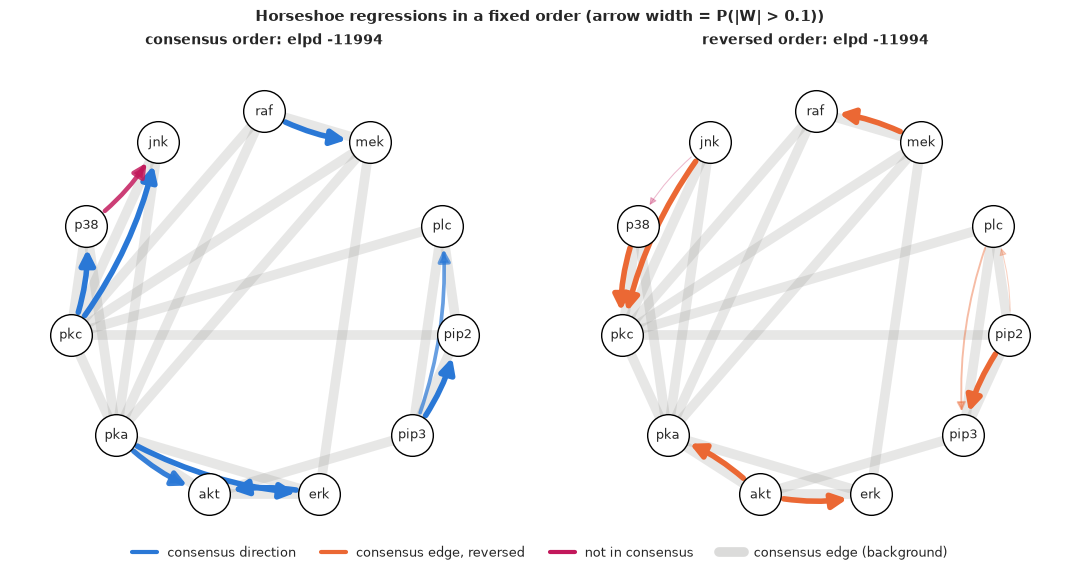

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5.6))
for ax, (name, Pm) in zip(axes, order_fits.items()):
    draw_dag(ax, Pm, f"{name}: elpd {float(order_loo[name].elpd):.0f}")
fig.legend(DAG_LEGEND, DAG_LABELS, loc="lower center", ncol=4, fontsize=9)
fig.suptitle("Horseshoe regressions in a fixed order (arrow width = P(|W| > 0.1))", fontsize=11);

Both fits are clean (at most one divergence, r_hat at most 1.02) - a fixed-order DAG has
none of NOTEARS' pathologies. And the two answers are opposite. In the consensus order, 8 of
the 9 edges found are consensus edges in the consensus direction (plus p38 $\to$ Jnk). In
the reversed order every one of the 6 edges is a consensus edge pointing the wrong way. LOO
cannot choose: 0.6 elpd apart with a standard error of 3.1.

The two graphs even differ in size, and the reason is instructive. In the consensus order
Akt comes after both Erk and PKA, so Erk $\to$ Akt $\leftarrow$ PKA is a collider - which
claims Erk and PKA are independent. They are not (correlation 0.36), so the model must add a
direct PKA $\to$ Erk edge to explain it. In the reversed order Akt comes first and
Erk $\leftarrow$ Akt $\to$ PKA says exactly what the data say (E19: Erk and PKA are
independent given Akt) with one edge fewer. The same happens at PKC, where the reversed
order's collider p38 $\to$ PKC $\leftarrow$ Jnk replaces the consensus order's three-edge
triangle. A sparsity prior therefore prefers some orders over others, but only weakly, and not
for causal reasons. **Given the order, learning the DAG is easy. The order is the hard part.**

## 5 · Averaging over every order exactly

If the order is the unknown, the Bayesian answer is to average over it. For 11 nodes that
sounds hopeless - $11! \approx 4 \times 10^7$ orders, each with its own sparse regressions - but
with a closed-form, **decomposable** score it is not. Restrict each node to at most 3 parents
(176 candidate parent sets per node) and score every family once with BGe. The posterior of
an order is then a product over nodes of "sum over the parent sets allowed by the order", and
Koivisto & Sood (2004) showed that the sum over *all* orders collapses into a dynamic
programme over the $2^{11} = 2048$ subsets of nodes: a forward pass (which nodes come first),
a backward pass (which come last), and every directed-edge probability $P(k \to j \mid \text{data})$
exactly - no MCMC, no convergence diagnostics.

The price is the prior. Summing over orders gives each DAG weight in proportion to the number
of orders it is consistent with (the **order-modular** prior): a DAG with a hub at the top is
consistent with more orders than a chain. We use a uniform prior over parent-set sizes
($1/\binom{10}{|\text{pa}|}$) and keep the order-modular bias in mind; Eaton & Murphy (2007) show how
to correct for it with importance sampling.

In [14]:
MAX_PARENTS = 3
PARENT_SETS = [pa for r_ in range(MAX_PARENTS + 1) for pa in itertools.combinations(range(P), r_)]


def local_scores(Zd, INTd):
    """log BGe family score + log prior for every node and candidate parent set. A node's family
    is scored only on the cells in which it was NOT intervened (INTd[:, j] False)."""
    S = np.full((P, len(PARENT_SETS)), -np.inf)
    for j in range(P):
        stats = bge_stats(Zd[~INTd[:, j]])
        for s, pa in enumerate(PARENT_SETS):
            if j not in pa:
                S[j, s] = family_score(stats, j, pa) - np.log(comb(P - 1, len(pa)))
    return S


def edge_posteriors(S):
    """Exact P(k -> j | data) under the order-modular prior (Koivisto & Sood 2004)."""
    NS, full = 1 << P, (1 << P) - 1
    subsets = np.arange(NS)
    pa_mask = np.array([sum(1 << k for k in pa) for pa in PARENT_SETS])
    allowed = (pa_mask[None, :] & ~subsets[:, None]) == 0     # [U, s]: parent set s lies inside U
    alpha = np.stack([logsumexp(np.where(allowed, S[j], -np.inf), axis=1) for j in range(P)])
    by_size = sorted(subsets[1:], key=lambda u: bin(u).count("1"))
    fwd, bwd = np.full(NS, -np.inf), np.full(NS, -np.inf)
    fwd[0] = bwd[0] = 0.0
    for U in by_size:                  # fwd[U]: all orders of U placed first
        fwd[U] = logsumexp([alpha[i, U & ~(1 << i)] + fwd[U & ~(1 << i)] for i in range(P) if U >> i & 1])
    for T in by_size:                  # bwd[T]: all orders of T placed last
        bwd[T] = logsumexp([alpha[i, full & ~T] + bwd[T & ~(1 << i)] for i in range(P) if T >> i & 1])
    E = np.zeros((P, P))
    for j in range(P):
        for k in range(P):
            if j == k:
                continue
            with_k = logsumexp(np.where(allowed & ((pa_mask >> k) & 1 == 1), S[j], -np.inf), axis=1)
            U = subsets[((subsets >> j) & 1 == 0) & ((subsets >> k) & 1 == 1)]
            E[k, j] = np.exp(logsumexp(fwd[U] + with_k[U] + bwd[full & ~U & ~(1 << j)]) - fwd[full])
    return E


t0 = time.time()
E_obs = edge_posteriors(local_scores(Z, np.zeros_like(Z, bool)))
print(f"exact edge posteriors over all orders of 11 nodes: {time.time() - t0:.1f} s")


def consensus_score(E):
    """Expected counts under the posterior (no thresholds)."""
    both = E + E.T
    return {"consensus edges found (either way)": both[IU][SKEL[IU]].sum(),
            "... in the consensus direction": E[TRUE].sum(),
            "... reversed": E.T[TRUE].sum(),
            "edges not in the consensus": both[IU][~SKEL[IU]].sum(),
            "undirected pairs with P > 0.5": (both[IU] > 0.5).sum()}


pd.Series(consensus_score(E_obs)).round(2)

exact edge posteriors over all orders of 11 nodes: 0.5 s


consensus edges found (either way)    6.66
... in the consensus direction        2.13
... reversed                          4.54
edges not in the consensus            0.22
undirected pairs with P > 0.5         7.00
dtype: float64

In [15]:
def direction_table(E):
    """Every pair with P(edge) > 0.3: consensus pairs written in the consensus direction."""
    rows = []
    for k, j in zip(*IU):
        a, b = (j, k) if TRUE[j, k] else (k, j)
        if E[a, b] + E[b, a] > 0.3:
            rows.append({"edge": f"{V[a]} → {V[b]}", "in consensus": bool(TRUE[a, b]), "P(edge)": E[a, b] + E[b, a],
                         "P(as written)": E[a, b], "P(reversed)": E[b, a]})
    return pd.DataFrame(rows).sort_values(["in consensus", "P(edge)"], ascending=False).round(2)


direction_table(E_obs)

,edge,in consensus,P(edge),P(as written),P(reversed)
0,raf → mek,True,1.00,0.50,0.50
3,erk → akt,True,1.00,0.25,0.75
5,pkc → p38,True,1.00,0.03,0.97
2,pip3 → pip2,True,1.00,0.61,0.39
6,pkc → jnk,True,1.00,0.03,0.97
4,pka → akt,True,1.00,0.25,0.75
1,pip3 → plc,True,0.59,0.41,0.19


The whole calculation takes under a second. The first table counts, in expectation under the
posterior, how many consensus edges are found (6.7 of 20 - the same seven-or-so pairs that E19
found as partial correlations), how many point the consensus way (2.1), and how many the
other way (4.5). Fewer than one in three of the found edges is oriented as in the literature:
worse than a coin. The second table shows where every number comes from:

- **Raf-Mek: 0.50 / 0.50.** An isolated edge, nothing to orient it: Markov equivalence in its
  purest form.
- **Erk-Akt and PKA-Akt: 0.25 / 0.75.** Erk - Akt - PKA has no v-structure, so the three
  orientations (two chains and the fork Erk $\leftarrow$ Akt $\to$ PKA) are equivalent. The
  fork fits two orders of the three nodes, each chain one, so the order-modular prior gives
  the fork 1/2 and the chains 1/4 each - and $P(\text{Akt} \to \text{Erk}) = 1/2 + 1/4$. The
  0.75 is **pure prior**.
- **PKC-p38 and PKC-Jnk: 0.03 / 0.97.** The collider of section 2, now inside the full
  network: the only strongly oriented arrows in the observational posterior, and both point
  against the consensus.

## 6 · Interventions break the symmetry

An intervention changes the mechanism of the molecule it targets and leaves every other
mechanism alone. In a SEM, a *perfect* intervention on node $j$ in some cells is the
do-operator applied to those cells only: $X_j$ stops listening to its parents and gets a
distribution of its own, while every other equation keeps its coefficients. Direction becomes
visible because the two orientations now make different predictions: if PKA $\to$ Erk, then
manipulating PKA still moves Erk and the PKA-Erk dependence survives in the manipulated cells;
if Erk $\to$ PKA, manipulating PKA cuts the arrow and the dependence disappears.

Two practical decisions. First, the conditions differ in more than their target (PMA and
b2cAMP cells were not stimulated through CD3/CD28 at all), so every molecule gets its **own
mean in every condition**; only the slopes and noise sds are shared. Direction information then
comes from how the *dependence* changes, not from shifts in means. Second, what is the
target? First the raw material, the correlation of some key pairs per condition.

In [16]:
pairs_show = [("raf", "mek"), ("mek", "erk"), ("erk", "akt"), ("pka", "erk"), ("pka", "akt"), ("pkc", "p38"),
              ("pkc", "jnk"), ("plc", "pip2")]
corr = {}
for cond in ["cd3_cd28", "b2camp", "pma", "cd3_cd28+u0126", "cd3_cd28+psitect", "cd3_cd28+aktinhib", "cd3_cd28+g0076"]:
    R = np.corrcoef(Z_all[label == cond].T)
    corr[cond.replace("cd3_cd28+", "+")] = {f"{a}-{b}": R[V.index(a), V.index(b)] for a, b in pairs_show}
pd.DataFrame(corr).round(2)

,cd3_cd28,b2camp,pma,+u0126,+psitect,+aktinhib,+g0076
raf-mek,0.70,0.14,0.73,0.99,0.61,0.67,0.99
mek-erk,0.02,0.06,0.01,-0.02,-0.00,-0.00,0.02
erk-akt,0.87,0.91,0.93,0.49,0.87,0.88,0.96
pka-erk,0.36,0.65,0.49,0.76,0.38,0.30,0.13
pka-akt,0.42,0.75,0.63,0.62,0.49,0.53,0.07
pkc-p38,0.68,0.45,0.80,0.66,0.74,0.83,0.98
pkc-jnk,-0.27,0.43,0.57,0.49,-0.13,0.16,0.68
plc-pip2,0.08,0.23,0.56,0.22,0.11,0.14,0.98


- **PKA-Erk under b2cAMP (acts on PKA):** the correlation does not vanish, it goes *up*,
  0.36 to 0.65 (PKA-Akt 0.42 to 0.75). Under PKA $\to$ Erk that is allowed; under Erk $\to$ PKA
  it should be zero.
- **Raf-Mek under U0126 (acts on Mek):** 0.70 to 0.99. If U0126 cut Mek off from its parents,
  Raf $\to$ Mek would predict zero here. It predicts the opposite of what we see - so the
  do-model will conclude Mek $\to$ Raf.
- **Mek-Erk: between -0.02 and 0.06 in every condition.** The textbook kinase step of the MAPK
  cascade, a consensus edge, is linearly invisible in all seven conditions shown.
- **G06976 (acts on PKC)** pushes several correlations to 0.96-0.99 (Raf-Mek, PKC-p38, PLC-PIP2):
  in those cells many molecules move together. Such a condition is a strong perturbation, but
  not one that touches only PKC.

The picture of the two interventions we will model first:

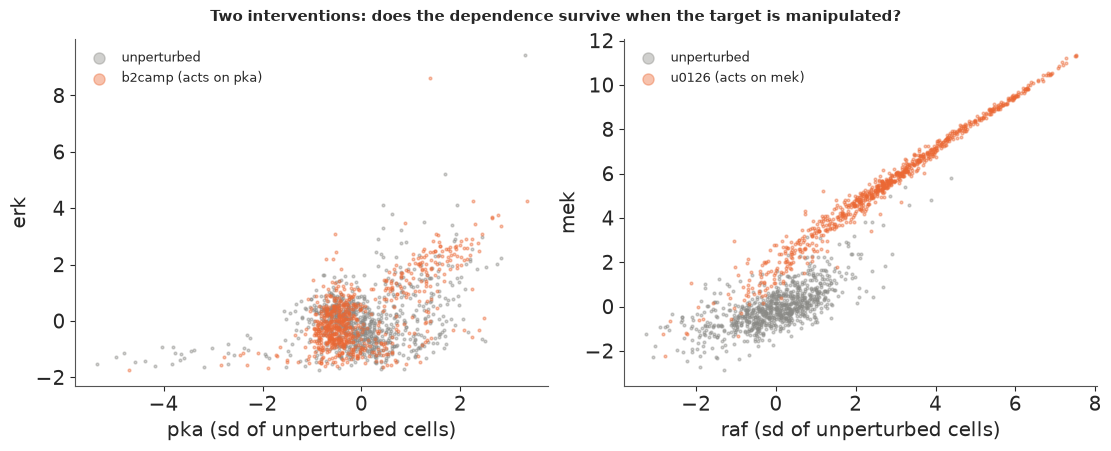

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, (a, b, cond, tgt) in zip(axes, [("pka", "erk", "b2camp", "pka"), ("raf", "mek", "cd3_cd28+u0126", "mek")]):
    for c, color, name in [("cd3_cd28", GREY, "unperturbed"), (cond, ORANGE, f"{cond.replace('cd3_cd28+', '')} (acts on {tgt})")]:
        rows_c = label == c
        ax.scatter(Z_all[rows_c, V.index(a)], Z_all[rows_c, V.index(b)], s=4, alpha=0.4, color=color, label=name)
    ax.set(xlabel=f"{a} (sd of unperturbed cells)", ylabel=b)
    ax.legend(fontsize=9, markerscale=4)
fig.suptitle("Two interventions: does the dependence survive when the target is manipulated?", fontsize=11);

In the b2cAMP cells (orange, left) PKA and Erk still rise together, even more clearly than in
the unperturbed cells. In the U0126 cells (right) phospho-Mek is up by several sd and lies on
an almost perfect line with Raf.

Now the PyMC version of the argument. `pair_model` already has the intervention built in: a
0/1 vector marks the cells in which the target was manipulated, and in those cells the
target's mean ignores its parent (`b * x_c * (1 - int_e)`) and its noise sd is a separate
parameter. That is the do-operator applied per cell, written as a mask. (`pm.do` from
section 2 does the same thing to *all* cells of a model at once, which is what you want for
predicting an experiment, not for fitting data from several.) We fit both orientations to
the unperturbed plus the b2cAMP cells, with PKA as the target.

In [18]:
pair_int = {}
for c, e in [("pka", "erk"), ("erk", "pka")]:
    _, idata, loo = fit_pair(c, e, ["cd3_cd28", "b2camp"], target="pka")
    report(idata, f"{c} -> {e}, + b2camp (do(pka))", ["b", "s_cause", "s_effect"])
    pair_int[f"{c} -> {e}"] = loo
    del idata
az.compare(pair_int, round_to=1)[["elpd", "elpd_diff", "dse", "p"]]

pka -> erk, + b2camp (do(pka)): divergences per chain [0, 2, 0, 0], max r_hat 1.002, min bulk ESS 2235


erk -> pka, + b2camp (do(pka)): divergences per chain [0, 0, 0, 0], max r_hat 1.002, min bulk ESS 2686


,elpd,elpd_diff,dse,p
pka -> erk,-4300.4,0.0,0.0,14.2
erk -> pka,-4457.0,-156.6,17.3,14.1


The tie of section 2 is gone: PKA $\to$ Erk now beats Erk $\to$ PKA by 157 elpd, nine standard
errors (two divergences in one chain, r_hat 1.002 in both fits). Nothing about the model changed except 707 cells in
which we know PKA was manipulated. This is the consensus direction.

The same code, pointed at Raf and Mek with the U0126 cells and Mek as the target:

In [19]:
pair_u0 = {}
for c, e in [("raf", "mek"), ("mek", "raf")]:
    _, idata, loo = fit_pair(c, e, ["cd3_cd28", "cd3_cd28+u0126"], target="mek")
    report(idata, f"{c} -> {e}, + u0126 (do(mek))", ["b", "s_cause", "s_effect"])
    pair_u0[f"{c} -> {e}"] = loo
    del idata
az.compare(pair_u0, round_to=1)[["elpd", "elpd_diff", "dse", "p"]]

raf -> mek, + u0126 (do(mek)): divergences per chain [0, 0, 0, 0], max r_hat 1.002, min bulk ESS 2509


mek -> raf, + u0126 (do(mek)): divergences per chain [0, 0, 0, 0], max r_hat 1.002, min bulk ESS 1637


,elpd,elpd_diff,dse,p
mek -> raf,-4441.7,0.0,0.0,11.1
raf -> mek,-5836.7,-1395.0,51.8,10.4


Mek $\to$ Raf, by 1395 elpd (27 standard errors) - the most decisive result in this notebook,
and it contradicts one of the best-established facts of the pathway: Raf phosphorylates Mek.
Nothing is wrong with the sampler or the data. The *model of the intervention* is wrong.
U0126 blocks Mek's kinase **activity**: it stops Mek from acting on Erk, but it does not stop
Raf from phosphorylating Mek, so the measured phospho-Mek still follows Raf (correlation 0.99).
"do(Mek)" - cutting the arrows *into* Mek - is the wrong surgery for an activity inhibitor; if
anything the right one cuts the arrows *out of* Mek. (Why phospho-Mek and Raf both climb so
far under U0126 is a further story - loss of negative feedback from Erk is the usual
explanation - and a feedback loop is something no DAG can represent.) With thousands of cells,
a misspecified intervention is not a small bias: it is certainty in the wrong direction.

### All 7466 cells, all orders

Back to the exact posterior of section 5, now with every cell. Only two lines of the BGe
machinery change: the data are the 7466 cells with each condition's means removed (the "own
mean per condition" decision), and a node's family is scored **only on the cells in which that
node was not intervened** - in the other cells its value was set from outside, so it says
nothing about how it depends on its parents (Cooper & Yoo 1999; Eaton & Murphy 2007). Its
parents are still scored there, as usual. We compare four versions: the 853 unperturbed cells
of section 5; all cells treated as observational; the two **activators** as perfect
interventions (the inhibitor conditions then count as observational cells with their own means);
and all seven reagents as perfect interventions on their named targets.

In [20]:
Z_cen = Z_all.copy()
for cond in np.unique(label):                   # a separate mean for every molecule in every condition
    Z_cen[label == cond] -= Z_cen[label == cond].mean(0)


def intervention_mask(kinds):
    M = np.zeros_like(Z_all, bool)
    for cond, (tgt, kind) in TARGETS.items():
        if kind in kinds:
            M[label == cond, V.index(tgt)] = True
    return M


E_int = {"853 unperturbed cells": E_obs}
for name, kinds in [("7466 cells, no targets", ()), ("7466 cells, activators as do()", ("activator",)),
                    ("7466 cells, all 7 reagents as do()", ("activator", "inhibitor"))]:
    E_int[name] = edge_posteriors(local_scores(Z_cen, intervention_mask(kinds)))
pd.DataFrame({k: consensus_score(E) for k, E in E_int.items()}).round(2)

,853 unperturbed cells,"7466 cells, no targets","7466 cells, activators as do()","7466 cells, all 7 reagents as do()"
consensus edges found (either way),6.66,8.02,8.02,8.02
... in the consensus direction,2.13,3.52,5.02,3.39
... reversed,4.54,4.51,3.00,4.63
edges not in the consensus,0.22,1.05,1.04,1.04
undirected pairs with P > 0.5,7.00,9.00,9.00,9.00


In [21]:
tri["7466, no targets"] = triple_posterior(Z_cen, intervention_mask(()), TRIPLE)[2]
tri["7466, activators as do()"] = triple_posterior(Z_cen, intervention_mask(("activator",)), TRIPLE)[2]
tri.drop(columns="log ML - max").sort_values("7466, activators as do()", ascending=False).head(7).round(3)

,DAG,class,"posterior, 853 unperturbed","7466, no targets","7466, activators as do()"
11,"pkc→p38, jnk→p38, pkc→jnk",7,0.094,0.167,0.5
7,"pkc→p38, pkc→jnk, p38→jnk",7,0.094,0.167,0.5
6,"pkc→p38, p38→jnk",6,0.000,0.000,0.0
5,"pkc→p38, pkc→jnk",5,0.002,0.000,0.0
21,"jnk→pkc, pkc→p38, jnk→p38",7,0.094,0.167,0.0
19,"jnk→pkc, pkc→p38",5,0.002,0.000,0.0
15,"p38→pkc, pkc→jnk, p38→jnk",7,0.094,0.167,0.0


**The summary table.** More cells find more of the skeleton (8.0 consensus pairs instead of
6.7, and about one extra non-consensus pair, p38-Jnk), but by themselves they orient nothing
better: 3.5 in the consensus direction against 4.5 reversed. Declaring the two activators as
interventions moves 1.5 edges from "reversed" to "right" (5.0 against 3.0). Declaring all
seven reagents as interventions undoes it (3.4 against 4.6).

**The PKC triangle** (the second table, same three molecules as section 2) shows the mechanism.
The unperturbed cells favoured the collider p38 $\to$ PKC $\leftarrow$ Jnk. Pooling all conditions
with their own means already removes it - the six complete DAGs share the posterior equally,
0.167 each, and cannot be told apart. Adding PMA as an intervention on PKC keeps exactly the
two complete DAGs in which **PKC is a parent of both p38 and Jnk**, at 0.5 each: the consensus
fork plus a p38-Jnk edge whose direction remains unknown (neither is a target).

The directed-edge probabilities for every pair that appears anywhere, as
P(consensus direction) / P(reversed):

In [22]:
rows = [(a, b) for a, b in zip(*np.nonzero(TRUE)) if max(E[a, b] + E[b, a] for E in E_int.values()) > 0.3]
rows += [(k, j) for k, j in zip(*IU) if not SKEL[k, j] and max(E[k, j] + E[j, k] for E in E_int.values()) > 0.3]
pd.DataFrame({name: [f"{E[a, b]:.2f} / {E[b, a]:.2f}" for a, b in rows] for name, E in E_int.items()},
             index=[f"{V[a]} → {V[b]}" + ("" if TRUE[a, b] else " (not in consensus)") for a, b in rows])

,853 unperturbed cells,"7466 cells, no targets","7466 cells, activators as do()","7466 cells, all 7 reagents as do()"
raf → mek,0.50 / 0.50,0.50 / 0.50,0.50 / 0.50,0.00 / 1.00
plc → pip2,0.00 / 0.01,0.50 / 0.50,0.50 / 0.50,0.00 / 1.00
pip3 → plc,0.41 / 0.19,0.50 / 0.50,0.50 / 0.50,0.37 / 0.63
pip3 → pip2,0.61 / 0.39,0.50 / 0.50,0.50 / 0.50,0.00 / 1.00
erk → akt,0.25 / 0.75,0.25 / 0.75,0.00 / 1.00,0.00 / 1.00
pka → akt,0.25 / 0.75,0.25 / 0.75,1.00 / 0.00,1.00 / 0.00
pkc → p38,0.03 / 0.97,0.50 / 0.50,1.00 / 0.00,1.00 / 0.00
pkc → jnk,0.03 / 0.97,0.50 / 0.50,1.00 / 0.00,1.00 / 0.00
p38 → jnk (not in consensus),0.03 / 0.03,0.50 / 0.50,0.50 / 0.50,0.50 / 0.50


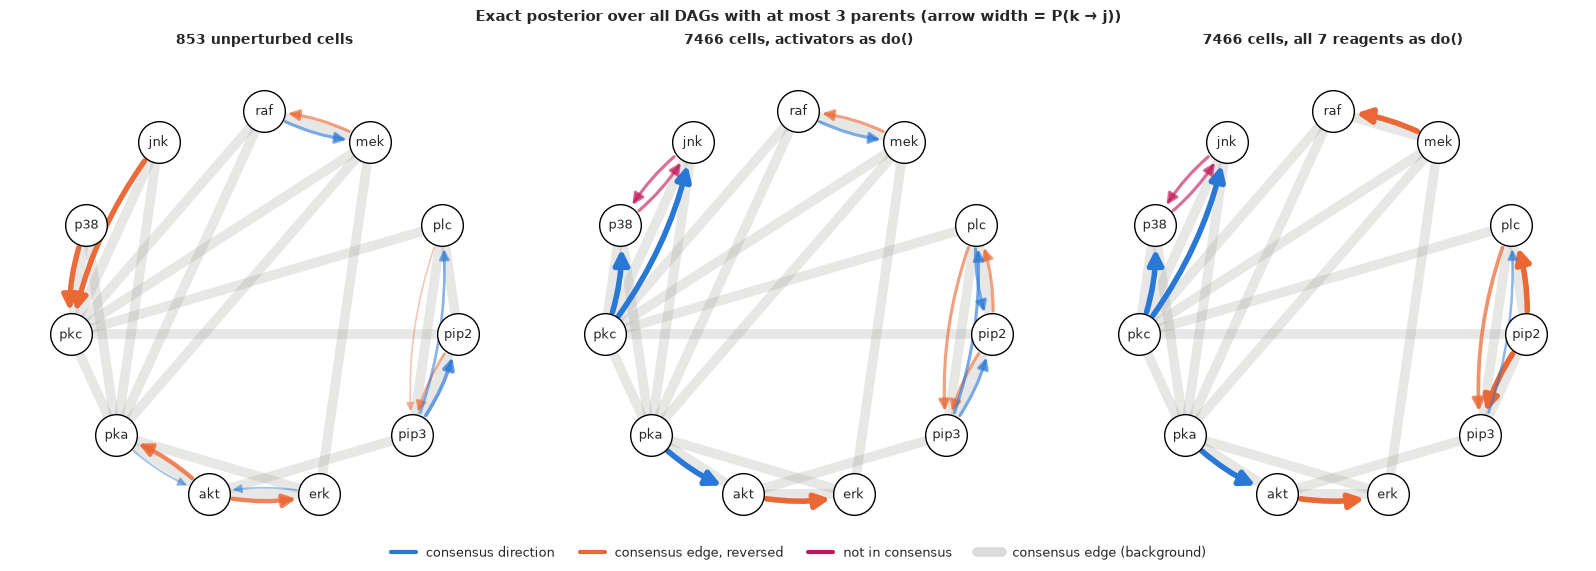

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.6))
for ax, name in zip(axes, ["853 unperturbed cells", "7466 cells, activators as do()", "7466 cells, all 7 reagents as do()"]):
    draw_dag(ax, E_int[name], name)
fig.legend(DAG_LEGEND, DAG_LABELS, loc="lower center", ncol=4, fontsize=9)
fig.suptitle("Exact posterior over all DAGs with at most 3 parents (arrow width = P(k → j))", fontsize=11);

Read the table and the three graphs together.

- **What the activators settle.** PKA $\to$ Akt, PKC $\to$ p38 and PKC $\to$ Jnk go to 1.00 in the
  consensus direction - the two collider arrows that pointed into PKC in the unperturbed cells
  are turned around. The interventions also orient an edge they do not touch: Akt $\to$ Erk at
  1.00, *against* the consensus. Once PKA $\to$ Akt is fixed, Erk - Akt - PKA can no longer be a
  collider at Akt (Erk and PKA are dependent, but independent given Akt), so the arrow must
  leave Akt towards Erk. Orientations propagate.
- **What nothing settles.** Raf-Mek, the PIP3-PLC-PIP2 triangle and p38-Jnk stay at 0.50 / 0.50:
  no activator touches them, and without an intervention the posterior is honest about not
  knowing.
- **What the inhibitors do.** Treated as do() on their measured targets, U0126, psitectorigenin
  and the rest flip Raf $\to$ Mek, PLC $\to$ PIP2 and PIP3 $\to$ PIP2 to certainty in the wrong
  direction (0.00 / 1.00), for the reason shown with Raf-Mek above: the edges *into* Mek and
  PIP2, the targets of U0126 and psitectorigenin, are reversed. (PKA $\to$ Akt, which points
  into the Akt inhibitor's target, keeps its consensus direction.)

**How far to trust the consensus.** It is a literature summary, not ground truth, and the data
argue with it in specific places. Mek $\to$ Erk has zero correlation in every condition: no
method working from these measurements can find it. The consensus has the triangle
Erk $\to$ Akt, PKA $\to$ Akt, PKA $\to$ Erk, while the data say Erk and PKA are independent given
Akt (E19) - either the PKA $\to$ Erk effect runs through Akt here, or it is too weak to see. And
"Erk $\to$ Akt" is itself one of the connections Sachs et al. reported as *new*, inferred from
these data, so scoring against it is partly scoring against another model's output.
Pathways also contain feedback loops that no DAG can represent. A precision of "5 of 8" against
the consensus is therefore a statement about agreement with a reference, not a measured error rate.

**How far to trust the posterior.** Almost every probability in the right-hand columns is 0.00,
0.50 or 1.00. That is what 7466 cells do to a posterior over discrete structures: every
structural claim the model can check at all is checked decisively. The probabilities are exact
*given* a linear-Gaussian, acyclic model with shared mechanisms across conditions and correctly
described interventions - and the inhibitor column shows that one wrong assumption among these
produces 1.00 just as easily as a right one. The honest uncertainty is in the choice between the
columns, and no posterior in this notebook quantifies it.

## 7 · Summary

| Question | Answer here |
|---|---|
| Can observational data orient an edge? | Only through v-structures. PKA $\to$ Erk vs Erk $\to$ PKA: 0.1 elpd apart (se 0.1); BGe scores of equivalent DAGs agree to every digit |
| Does the direction matter if the fit is identical? | Yes: `pm.do` - forcing PKA up 2 sd moves Erk by +0.71 sd under one model, 0.00 under the other |
| Bayesian NOTEARS? | $h(W) = \operatorname{tr} e^{W\circ W} - d$ as a `pm.Potential` works mechanically (expm has exact gradients). $\lambda = 100$: six two-cycles. $\lambda = 10^5$: acyclic, but each chain a different DAG (r_hat 1.74). Shared-variance loss follows the variance ordering on the raw scale (75-100% of arrows up the ladder vs 45% for the consensus) |
| Fixed order? | Clean horseshoe regressions; consensus order 8/9 edges right, reversed order 6/6 reversed, LOO tie (0.6 ± 3.1) |
| Exact averaging over orders? | BGe + Koivisto-Sood DP, 11 nodes, < 1 s: 6.7 consensus pairs, 2.1 oriented right, 4.5 reversed; the 0.75s are the order-modular prior |
| Interventions? | A per-cell mask on the target's equation. PKA $\to$ Erk by 157 elpd with b2cAMP. Activators as do(): 5.0 right vs 3.0 reversed. Inhibitors as do() on the measured target: certainty in the wrong direction (Mek $\to$ Raf by 1395 elpd) |
| The lesson | The data identify directions only through the assumptions about *what an intervention does*; get those wrong and more data make the answer more certain, not more right |

## Try it yourself

1. **Activity inhibitors cut outgoing edges.** Change `pair_model` so that in the U0126 cells
   it is Mek's *children* that stop listening to Mek (Raf $\to$ Mek keeps its equation; an
   Erk-on-Mek slope is switched off in those cells), and fit Raf/Mek and Mek/Erk both ways.
   Does the Raf $\to$ Mek direction survive? What does the Mek-Erk correlation table predict?
2. **Which chain was right?** For each of the four NOTEARS chains at $\lambda = 10^5$, turn its
   edge list into parent sets and compute its BGe score with `family_score`. Which chain found
   the best DAG, and is it Markov equivalent to any of the others? Then start NOTEARS at the
   consensus-order solution of section 4 (`initvals=`) and see whether the chains stay there.
3. **Unknown targets.** Give every node its own noise sd in every condition and a
   horseshoe-shrunk intercept shift, and let the data say which molecules each reagent really
   changes (the idea behind Eaton & Murphy's "uncertain interventions" and Mooij et al.'s *Joint
   Causal Inference*). Which conditions look like clean single-target interventions?